In [1]:
import pandas as pd 
import numpy as np
import os 
import xarray as xr 
import matplotlib.pyplot as plt
import cmocean as cmo 
import pandas as pd 
import numpy as np
import matplotlib.dates as mdates
import cmcrameri.cm as cmc

# Start date 
start_date = '2024-08-06'
end_date = '2024-08-28' 

Dates = pd.date_range(start_date, end_date, freq='10s')



def format_date_ax(ax, int=3):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)

In [2]:

fout = "/global/homes/s/siennaw/scratch/siennaw/scripts/phys_obs_paper/"
site = "WEB" # {'PLZ', 'WEB', 'TB'}
TEMP = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/turbulence-model/data/forcing_data/data/Temperature_processed.csv")
TEMP = TEMP.loc[TEMP.STAT == "Average"]
TEMP['time'] = pd.to_datetime(TEMP['TIMESTAMP'])
TEMP['day'] = TEMP['time'].dt.day

temp = TEMP.loc[TEMP.SITE == site]
temp.reset_index(inplace=True)
temp.drop(columns=['STAT', 'SITE', "SENSOR", "Interval", "TIMESTAMP"], inplace=True)
# print(temp)


import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)


/tmp/ipykernel_1132647/2140198767.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp.drop(columns=['STAT', 'SITE', "SENSOR", "Interval", "TIMESTAMP"], inplace=True)


In [3]:


unique_times = np.unique(temp.time.values)
DWL_OUT = pd.DataFrame(index=unique_times)
DWL_OUT['grad'] = np.nan
DWL_OUT['dwl'] = np.nan

for d in range(6, 27): 
    temp0 = temp.loc[temp.day == d]
    time = temp0.time.iloc[210: -70].values #Dates[ds.t.values]

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])
    maxs = np.nanmax(dT, axis=0)


    # axs[0].plot(X, -md,"-k", alpha=0.15)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')

    # mask = maxs>1
    mask = (X > time[0]) # Crop to daytime hours

    # mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])
    mask1 = mask # & (maxs > 0.9)

    for t,depth,grad in zip(X[mask1], averaged_md[mask1], maxs[mask1]):

        DWL_OUT.loc[t, 'dwl'] = depth
        DWL_OUT.loc[t, 'grad'] = grad


print(DWL_OUT)
DWL_OUT['time'] = DWL_OUT.index
DWL_OUT.reset_index(inplace=True, drop=True)
DWL_OUT.to_csv("%s/DWL_output_%s.csv" % (fout,site)) 


                     grad  dwl
2024-08-05 15:15:00   NaN  NaN
2024-08-05 15:30:00   NaN  NaN
2024-08-05 15:45:00   NaN  NaN
2024-08-05 16:00:00   NaN  NaN
2024-08-05 16:15:00   NaN  NaN
...                   ...  ...
2024-08-29 08:30:00   NaN  NaN
2024-08-29 08:45:00   NaN  NaN
2024-08-29 09:00:00   NaN  NaN
2024-08-29 09:15:00   NaN  NaN
2024-08-29 09:30:00   NaN  NaN

[2281 rows x 2 columns]


In [4]:
wind = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/wind/Wind_processed.csv")
wind = wind.loc[wind.STAT == "Average"]
wind = wind.loc[wind.SITE == "WEB"]
wind['time'] = pd.to_datetime(wind['TIMESTAMP'], format="%Y-%m-%dT%H:%M:%SZ")


In [5]:
# Chlorophyll-a data
chla = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/2024/august6-16/chla_for_adjoint.csv")
chla['time'] = pd.to_datetime(chla['time'])
obs = chla.pg_chla_perML 

# Rolling average to smooth the data
obs_roll = obs.rolling(window=10, center=True).mean()
chla['obs_roll'] = obs_roll

# mixed_depth = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/mixed_layer/TempDens_parametersbydepth.csv")
# mixed_depth = mixed_depth.loc[mixed_depth.SITE == "WEB"]
# mixed_depth['time'] = pd.to_datetime(mixed_depth['TIMESTAMP'])
# mixed_depth.loc[mixed_depth["Depth_MixedLayer_Max_60min_movavg"] > 5] = np.nan

AssertionError: 

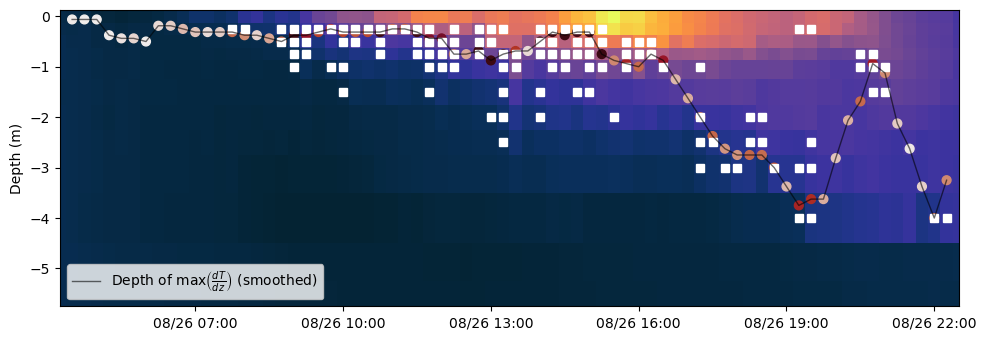

In [6]:
# define mixed depth
d = 22
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

if 1 : 
    for d in range(7, 27): 

        d = 26
        temp0 = temp.loc[temp.day == d]

    
        time = temp0.time.iloc[210: -70].values #Dates[ds.t.values]

        pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
        X = pivoted.columns.values
        Y = pivoted.index.values
        Z = pivoted.values

        fig = plt.figure(figsize=(10,3.5))
        ax = fig.gca() 

        # Caclulate DT/dz 
        dT = np.gradient(Z,  axis=1)/0.1
        dT[0,:] = 0
        zone = np.where(dT > 0.4)
        # print(dT.shape)
        # print(X.shape)
        # print(Y.shape)


        # print(X[zone[0]], -Y[zone[0]]) #, dT.shape, zone.shape)
        
        # c = ax.plot(X[zone[0]], -Y[zone[1]], 'bo') # s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5) 

        mixed_d = np.argmax(dT, axis=0)
        md = np.array([Y[i] for i in mixed_d])
        maxs = np.nanmax(dT, axis=0)

        b = ax.pcolormesh(X, -Y, Z, cmap=cmo.cm.thermal)

        # axs[0].plot(X, -md,"-k", alpha=0.15)
        conv = np.ones(4)/4
        averaged_md = np.convolve(md, conv, mode='same')

        # mask = maxs>1
        mask = (X > time[0]) # Crop to daytime hours

        # mask = mask & (X > time[0]) # Crop to daytime hours
        mask = mask & (X < time[-1])


        for i,j in zip(zone[0], zone[1]):
            # print(X[j], -Y[i])
            ax.plot(X[j], -Y[i], 'ws')

        # axs[1].plot(X[mask], -averaged_md[mask], '--',   color="#BF0F0F" , linewidth=4, alpha=0.58)
        ax.plot(X[mask], -averaged_md[mask], '-', color="k",linewidth=1, alpha=0.58, label=r"Depth of max$\left( \frac{dT}{dz} \right)$ (smoothed)")
        c = ax.scatter(X[mask], -averaged_md[mask], c=maxs[mask], s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5) 

        # plt.colorbar(b, ax=ax, label=r'Temperature ($^{\circ}$C)', orientation='vertical', shrink = 0.63) 
        # plt.colorbar(c, ax=ax, label=r"Temperature gradient ($^{\circ}$C m$^{-1}$)" , orientation='horizontal', shrink = 0.43 , pad=0.15) 
        ax.set_xlim(time[0], time[-1])
        format_date_ax(ax)
        ax.set_ylabel("Depth (m)")
        ax.legend(loc='lower left')
        plt.tight_layout()
        assert(False)
        # fig.savefig("%s/dwl_august_%02d_%s.png" % (fout, d, site), dpi=300)
        # plt.close()
        


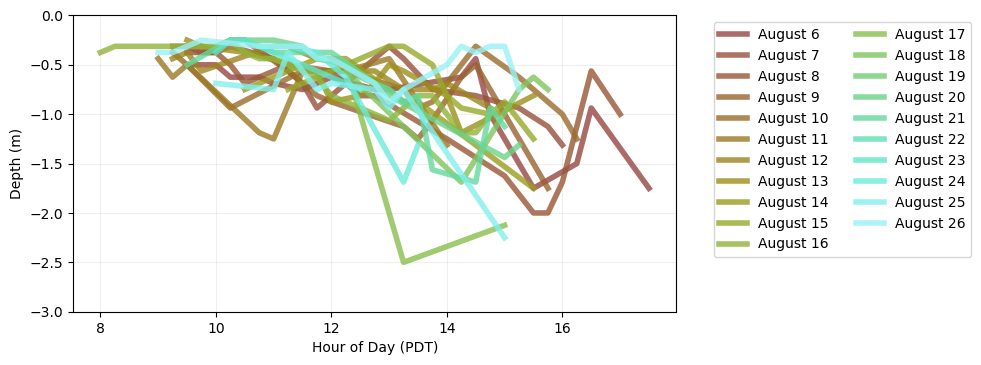

In [ ]:
# define mixed depth
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)


fig = plt.figure(figsize=(10,3.5))
ax = fig.gca() 

for d in range(6, 27): 
    temp0 = temp.loc[temp.day == d]

 
    time = temp0.time.iloc[210: -70].values #Dates[ds.t.values]

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])
    maxs = np.nanmax(dT, axis=0)


    # axs[0].plot(X, -md,"-k", alpha=0.15)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')

    # mask = maxs>1
    mask = (X > time[0]) # Crop to daytime hours

    # mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])
    mask = mask & (maxs > 1)

    time0 = X[mask]
    time0 = [i.hour + i.minute/60 for i in pd.to_datetime(time0)]
    if d%1 == 0:
        ax.plot(time0[0:-2], -averaged_md[mask][0:-2], '-', color=cmc.hawaii(d/27),linewidth=4, alpha=0.8, label="August %d" % d) #
    else:
        ax.plot(time0[0:-2], -averaged_md[mask][0:-2], '-', color=cmc.hawaii(d/27),linewidth=4, alpha=0.8) #
    ax.set_ylabel("Depth (m)")


ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncols=2) 
plt.tight_layout()
ax.set_ylim(-3, 0)
ax.grid(alpha=0.2)
ax.set_xlabel("Hour of Day (PDT)")
plt.show()

# fig.savefig("%s/dwl_all_days_%s.png"  % (fout, site), dpi=300)

    # assert(False)

        # , label=r"Depth of max$\left( \frac{dT}{dz} \right)$ (smoothed)")

    


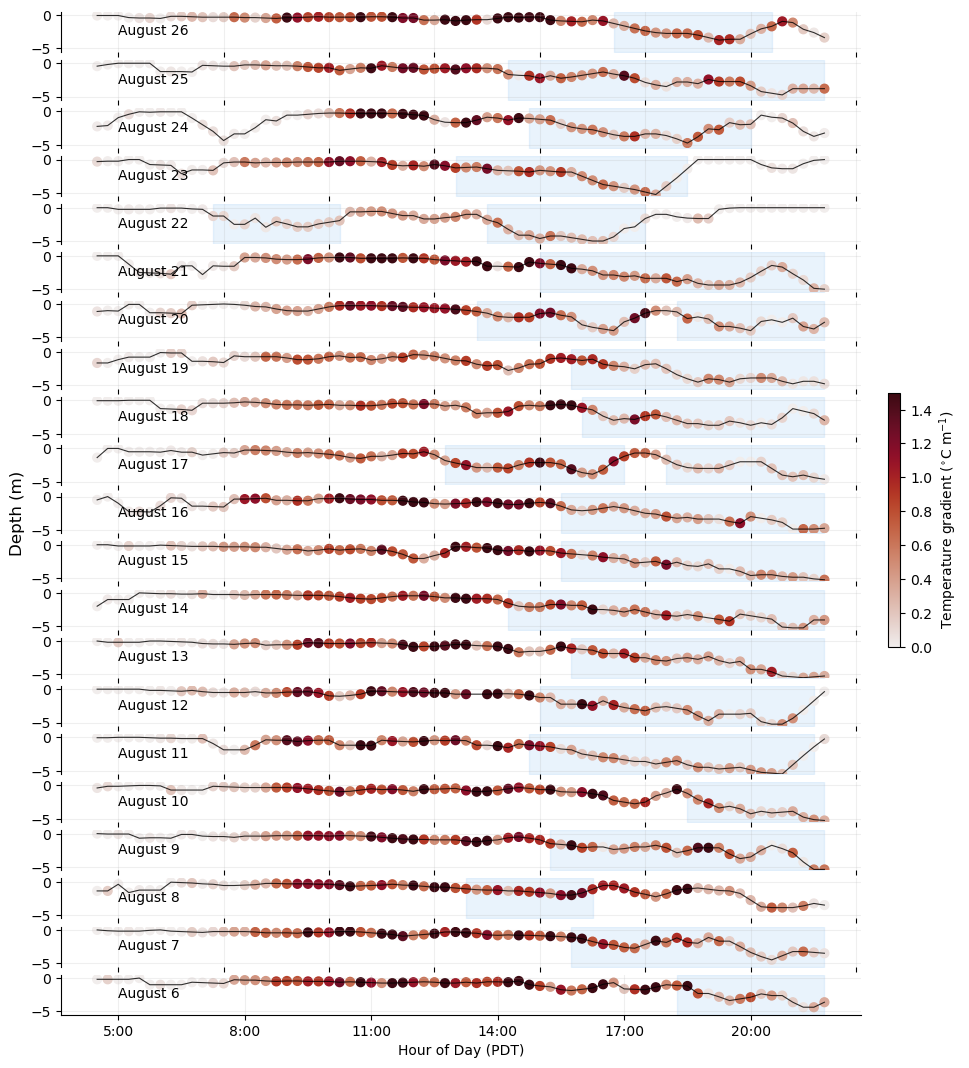

In [ ]:
# define mixed depth
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)


fig = plt.figure(figsize=(10,10))
ax = fig.gca() 
ax.axis('off')

DWL_OUT = pd.DataFrame(index=temp0.time.values)
DWL_OUT['grad'] = np.nan
DWL_OUT['dwl'] = np.nan

for d in range(6, 27): 
    temp0 = temp.loc[temp.day == d]

 
    time = temp0.time.iloc[210: -70].values #Dates[ds.t.values]

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])
    maxs = np.nanmax(dT, axis=0)


    # axs[0].plot(X, -md,"-k", alpha=0.15)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')

    # mask = maxs>1
    mask = (X > time[0]) # Crop to daytime hours

    # mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])
    mask1 = mask # & (maxs > 0.9)

    time0 = X[mask1]
    time0 = [i.hour + i.minute/60 for i in pd.to_datetime(time0)]

    offset = (d-6)/27 * 1.3
    ax1 = fig.add_axes([0.05, offset, 0.8, 0.04])


    # highlight areas where the DWL < -1.5 m
    below = -averaged_md[mask1][0:-2] < -1 
    s = pd.Series(below)
    runs = s.ne(s.shift()).cumsum()

    # keep True only if run length >= 3
    out = s & (s.groupby(runs).transform('sum') >= 13)
    ax1.fill_between(time0[0:-2], 0, 1, where=out, transform=ax1.get_xaxis_transform(), color='#71B4F0', alpha=0.15)

    ax1.plot(time0[0:-2], -averaged_md[mask1][0:-2], '-', color='k',linewidth=0.8, alpha=0.8, label="August %d" % d) #
    c = ax1.scatter(time0[0:-2], -averaged_md[mask1][0:-2], c=maxs[mask1][0:-2], s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5) 

    for t,depth,grad in zip(X[mask1], averaged_md[mask1], maxs[mask1]):

        DWL_OUT.loc[t, 'dwl'] = depth
        DWL_OUT.loc[t, 'grad'] = grad

    if site == "WEB":
        ax1.set_ylim(-5.5, 0.5)
        ax1.annotate("August %d" % d, (5, -3))

    elif site == "TB":
        ax1.set_ylim(-9, 0.5)
        ax1.annotate("August %d" % d, (3, -5))

    else: 
        ax1.set_ylim(-3.5, 0.5)
        ax1.annotate("August %d" % d, (3, -1))

    ax1.grid(alpha=0.2)
    if d > 6:
        ax1.spines['bottom'].set_visible(False)
        ax1.xaxis.set_ticklabels([])
    else:
        ax1.set_xticks(np.arange(5, 22, 3))
        ax1.set_xticklabels(['5:00', '8:00', '11:00', '14:00', '17:00', '20:00'])
        ax1.set_xlabel("Hour of Day (PDT)")

    
    ax1.spines['right'].set_visible(False)
    ax1.spines['top'].set_visible(False)
    if d == 16:
        ax1.set_ylabel("Depth (m)", fontsize=12)

plt.colorbar(c, ax=ax, label=r"Temperature gradient ($^{\circ}$C m$^{-1}$)" , orientation='vertical', shrink = 0.33 , anchor=(0.9,0.5)) # pad=-0.2) #.95) 


#     assert(False)


# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncols=2) 


# ax.set_xlabel("Hour of Day (PDT)")
# plt.show()

fig.savefig("%s/dwl_all_days_ridge_%s.png" % (fout, site), dpi=300,  bbox_inches="tight")

    # assert(False)

        # , label=r"Depth of max$\left( \frac{dT}{dz} \right)$ (smoothed)")


In [ ]:
# with wind
# define mixed depth
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

if 0: 
    for d in range(6, 27): 
        temp0 = temp.loc[temp.day == d]

    
        time = temp0.time.iloc[210: -70].values #Dates[ds.t.values]

        pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
        X = pivoted.columns.values
        Y = pivoted.index.values
        Z = pivoted.values

        fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10,4), height_ratios=(0.5, 1.5), sharex=True, constrained_layout=True)

        # Caclulate DT/dz 
        dT = np.gradient(Z,  axis=1)/0.1
        dT[0,:] = 0
        mixed_d = np.argmax(dT, axis=0)
        md = np.array([Y[i] for i in mixed_d])
        maxs = np.nanmax(dT, axis=0)

        b = axs[1].pcolormesh(X, -Y, Z, cmap=cmo.cm.thermal)

        # axs[0].plot(X, -md,"-k", alpha=0.15)
        conv = np.ones(4)/4
        averaged_md = np.convolve(md, conv, mode='same')

        # mask = maxs>1
        mask = (X > time[0]) # Crop to daytime hours

        axs[0].plot(wind.time, wind.WindSpeed**3, '-k')
        axs[0].set_xlim(time[0], time[-1])
        axs[0].set_ylim(0, 170)
        axs[0].grid(alpha=0.3)
        axs[0].set_ylabel("Wind$^3$ [m/s]$^3$")
        axs[0].set_ylim(0,100)
        # mask = mask & (X > time[0]) # Crop to daytime hours
        mask = mask & (X < time[-5])

        # axs[1].plot(X[mask], -averaged_md[mask], '--',   color="#BF0F0F" , linewidth=4, alpha=0.58)
        axs[1].plot(X[mask], -averaged_md[mask], '-', color="k",linewidth=1, alpha=0.58, label=r"Depth of max$\left( \frac{dT}{dz} \right)$ (smoothed)")

        c = axs[1].scatter(X[mask], -averaged_md[mask], c=maxs[mask], s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5) 
        plt.colorbar(c, ax=ax, label=r"Temperature gradient ($^{\circ}$C m$^{-1}$)" , orientation='horizontal', shrink = 0.43 , pad=0.15) 

        plt.colorbar(b, ax=axs[1], label=r'Temperature ($^{\circ}$C)', orientation='vertical', shrink = 0.83, pad=0.01) 
        plt.colorbar(c, ax=axs[1], label=r"Temperature gradient ($^{\circ}$C m$^{-1}$)" , orientation='horizontal', shrink = 0.23 , pad=0.04) 
        ax.set_xlim(time[0], time[-1])
        format_date_ax(axs[1])
        axs[1].set_ylabel("Depth (m)")
        axs[1].legend(loc='lower left')
        # plt.tight_layout()
        # plt.show() 
        # assert(False)
        fig.savefig("%s/dwl_wind_august_%02d_%s.png" % (fout, d,site), dpi=300)
        plt.close()


Text(0.5, 0, 'Temperature gradient ($^{\\circ}$C m$^{-1}$)')

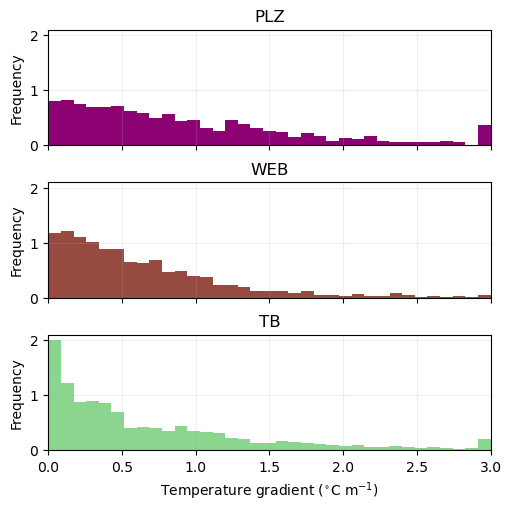

In [ ]:
# Histogram of DWL depth and gradient


def generate_hist_data(temp, site):
    dts = [] 
    temp = TEMP.loc[TEMP.SITE == site]

    for d in range(6, 27): 
        temp0 = temp.loc[temp.day == d]


        time = temp0.time.iloc[210: -70].values #Dates[ds.t.values]

        pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
        X = pivoted.columns.values
        Y = pivoted.index.values
        Z = pivoted.values

        # Caclulate DT/dz 
        dT = np.gradient(Z,  axis=1)/0.1
        dT[0,:] = 0
        mixed_d = np.argmax(dT, axis=0)
        md = np.array([Y[i] for i in mixed_d])
        maxs = np.nanmax(dT, axis=0)


        # axs[0].plot(X, -md,"-k", alpha=0.15)
        conv = np.ones(4)/4
        averaged_md = np.convolve(md, conv, mode='same')

        # mask = maxs>1
        mask = (X > time[0]) # Crop to daytime hours


        # mask = mask & (X > time[0]) # Crop to daytime hours
        mask = mask & (X < time[-5])
        values = maxs[mask]
        values = np.clip(values, 0, 3)
        values = values[values>0]
        dts.append(values)

    return dts 



colors = [cmc.hawaii(d/21) for d in range(0, 21)]


NBINS = 35
fig,axs = plt.subplots(nrows=3, ncols=1, figsize=(5,5), sharex=True, sharey=True, constrained_layout=True)
dts = generate_hist_data(TEMP, 'PLZ')
axs[0].hist(np.concat(dts), stacked=True, bins =NBINS, density=True, color=colors[0])   
axs[0].set_title("PLZ")

dts = generate_hist_data(TEMP, 'WEB')
axs[1].hist(np.concat(dts), stacked=True, bins =NBINS, density=True, color=colors[5])  
axs[1].set_title("WEB")
dts = generate_hist_data(TEMP, 'TB')
axs[2].hist(np.concat(dts), stacked=False, bins =NBINS, density=True, color=colors[15], alpha=0.84)  
axs[2].set_title("TB")
for ax in axs:
    ax.set_xlim(0, 3)
    ax.grid(alpha=0.2)
    ax.set_ylabel("Frequency")
axs[2].set_xlabel(r"Temperature gradient ($^{\circ}$C m$^{-1}$)")


Text(0.5, 0, 'Depth of DWL (m)')

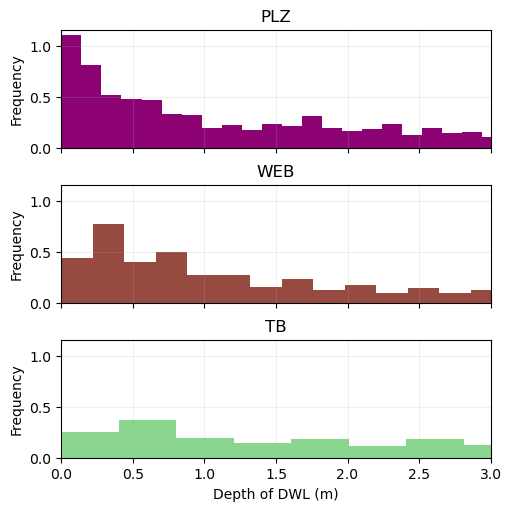

In [ ]:
# Histogram of DWL depth and gradient


def generate_hist_data(temp, site):
    dts = [] 
    temp = TEMP.loc[TEMP.SITE == site]

    for d in range(6, 27): 
        temp0 = temp.loc[temp.day == d]


        time = temp0.time.iloc[210: -70].values #Dates[ds.t.values]

        pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
        X = pivoted.columns.values
        Y = pivoted.index.values
        Z = pivoted.values

        # Caclulate DT/dz 
        dT = np.gradient(Z,  axis=1)/0.1
        dT[0,:] = 0
        mixed_d = np.argmax(dT, axis=0)
        md = np.array([Y[i] for i in mixed_d])
        maxs = np.nanmax(dT, axis=0)

        conv = np.ones(4)/4
        averaged_md = np.convolve(md, conv, mode='same')

        mask = (X > time[0]) # Crop to daytime hours
        # mask = mask & (X > time[0]) # Crop to daytime hours
        mask = mask & (X < time[-5])
        values = averaged_md[mask]

        dts.append(values)

    return dts 



colors = [cmc.hawaii(d/21) for d in range(0, 21)]


NBINS = 25
fig,axs = plt.subplots(nrows=3, ncols=1, figsize=(5,5), sharex=True, sharey=True, constrained_layout=True)
dts = generate_hist_data(TEMP, 'PLZ')
axs[0].hist(np.concat(dts), stacked=True, bins =NBINS, density=True, color=colors[0])   
axs[0].set_title("PLZ")

dts = generate_hist_data(TEMP, 'WEB')
axs[1].hist(np.concat(dts), stacked=True, bins =NBINS, density=True, color=colors[5])  
axs[1].set_title("WEB")
dts = generate_hist_data(TEMP, 'TB')
axs[2].hist(np.concat(dts), stacked=False, bins =NBINS, density=True, color=colors[15], alpha=0.84)  
axs[2].set_title("TB")
for ax in axs:
    ax.set_xlim(0, 3)
    ax.grid(alpha=0.2)
    ax.set_ylabel("Frequency")
axs[2].set_xlabel(r"Depth of DWL (m)")


2024-08-16T04:45:00.000000000 2024-08-16T19:00:00.000000000
2024-08-17T04:45:00.000000000 2024-08-17T19:00:00.000000000
2024-08-22T04:45:00.000000000 2024-08-22T19:00:00.000000000


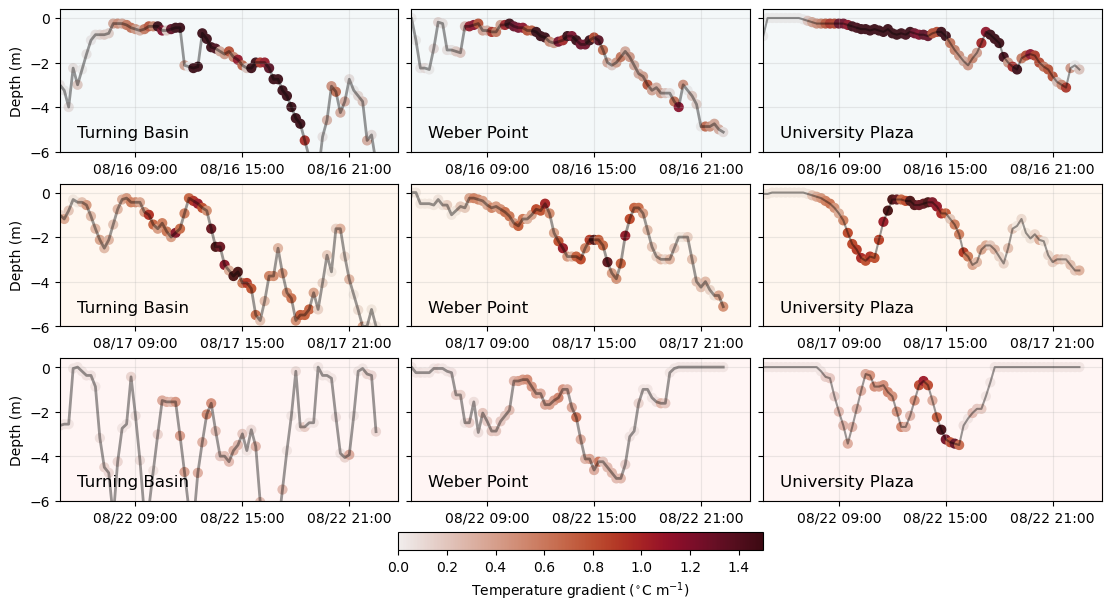

In [ ]:


dwl_tb = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/scripts/phys_obs_paper/DWL_output_TB.csv", parse_dates=['time'])
dwl_wp = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/scripts/phys_obs_paper/DWL_output_WEB.csv", parse_dates=['time'])
dwl_up = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/scripts/phys_obs_paper/DWL_output_PLZ.csv", parse_dates=['time'])


fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(11,6), sharex=False, sharey=True, constrained_layout=True)
# axs = axs.flatten()
colors= [ "#99BECC", "#FFBA6C", "#FFA299"]
for i, d in enumerate([16, 17, 22]):
    dwl_up_day = dwl_up.loc[dwl_up.time.dt.day == d]

    axs[i,2].plot(dwl_up_day.time, -dwl_up_day.dwl, color="k", label="PLZ", alpha=0.4)
    axs[i,2].scatter(dwl_up_day.time, -dwl_up_day.dwl, c=dwl_up_day.grad, s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5)

    dwl_wp_day = dwl_wp.loc[dwl_wp.time.dt.day == d]
    axs[i, 1].plot(dwl_wp_day.time, -dwl_wp_day.dwl, color="k", label="PLZ", alpha=0.4, linewidth=2)
    axs[i, 1].scatter(dwl_wp_day.time, -dwl_wp_day.dwl, c=dwl_wp_day.grad, s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5)

    dwl_tb_day = dwl_tb.loc[dwl_tb.time.dt.day == d]
    axs[i, 0].plot(dwl_tb_day.time, -dwl_tb_day.dwl, color="k", label="PLZ", alpha=0.4, linewidth=2)
    h= axs[i, 0].scatter(dwl_tb_day.time, -dwl_tb_day.dwl, c=dwl_tb_day.grad, s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5)

    # print(dwl_tb_day.time)
    axs[i, 2].fill_between(dwl_tb_day.time, 1, -6, color=colors[i], alpha=0.1)
    axs[i, 1].fill_between(dwl_tb_day.time,1, -6, color=colors[i], alpha=0.1)
    axs[i, 0].fill_between(dwl_tb_day.time,1, -6, color=colors[i], alpha=0.1)

    print(dwl_tb_day.time.values[19], dwl_tb_day.time.values[-20])
    axs[i, 2].set_xlim(dwl_tb_day.time.values[19], dwl_tb_day.time.values[-1])
    axs[i, 1].set_xlim(dwl_tb_day.time.values[19], dwl_tb_day.time.values[-1])
    axs[i, 0].set_xlim(dwl_tb_day.time.values[19], dwl_tb_day.time.values[-1])

    axs[i, 0].annotate("Turning Basin", (0.05, 0.1), xycoords='axes fraction', fontsize=12)
    axs[i, 1].annotate("Weber Point", (0.05, 0.1), xycoords='axes fraction', fontsize=12)
    axs[i, 2].annotate("University Plaza", (0.05, 0.1), xycoords='axes fraction', fontsize=12)


# axs[0, 2].set_title("Turning Basin")
# axs[0, 1].set_title("Weber Point")
# axs[0, 0].set_title("University Plaza")

axs[0, 0].set_ylabel("Depth (m)")
axs[1, 0].set_ylabel("Depth (m)")
axs[2, 0].set_ylabel("Depth (m)")


for ax in axs.flatten():
    format_date_ax(ax, int=6)
    ax.set_ylim(-6, 0.4)
    ax.grid(alpha=0.25)

plt.colorbar(h, label=r'Temperature gradient ($^{\circ}$C m$^{-1}$)', shrink=0.35, orientation='horizontal', ax=axs[2])
fig.savefig("%s/dwl_Ordered.png" % fout, dpi=300, bbox_inches="tight")

In [ ]:


unique_times = np.unique(temp.time.values)


for d in range(6, 27): 
    temp0 = temp.loc[temp.day == d]
    # time = temp0.time.iloc[210: -70].values #Dates[ds.t.values]

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])
    maxs = np.nanmax(dT, axis=0)


    # axs[0].plot(X, -md,"-k", alpha=0.15)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')

    # mask = maxs>1
    mask = (X > time[0]) # Crop to daytime hours

    # mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])
    mask1 = mask # & (maxs > 0.9)




(12, 96)
[0.   0.5  1.5  2.5  3.   3.5  4.   4.5  4.75 5.   5.25 5.5 ]
best params: A, C, lam =  (np.float64(0.08680000000000021), np.float64(0.0), np.float64(0.3925925925925926))
best params: A, C, lam =  (np.float64(0.186399999999999), np.float64(11.0), np.float64(1.5629629629629633))
best params: A, C, lam =  (np.float64(0.3265999999999991), np.float64(5.210526315789474), np.float64(1.5629629629629633))


/tmp/ipykernel_2351786/3194317420.py:16: RuntimeWarning: invalid value encountered in divide
  return A*(np.tanh((z-C)/lam)-np.tanh((z[0]-C)/lam))/(np.max(np.tanh((z-C)/lam)-np.tanh((z[0]-C)/lam)))


best params: A, C, lam =  (np.float64(0.6947499999999991), np.float64(4.631578947368421), np.float64(0.3925925925925926))
best params: A, C, lam =  (np.float64(1.2335999999999991), np.float64(4.052631578947368), np.float64(0.6851851851851852))
best params: A, C, lam =  (np.float64(1.368000000000002), np.float64(9.263157894736842), np.float64(8.0))
best params: A, C, lam =  (np.float64(1.124600000000001), np.float64(0.5789473684210527), np.float64(3.9037037037037043))
best params: A, C, lam =  (np.float64(0.3205999999999989), np.float64(0.5789473684210527), np.float64(1.2703703703703706))


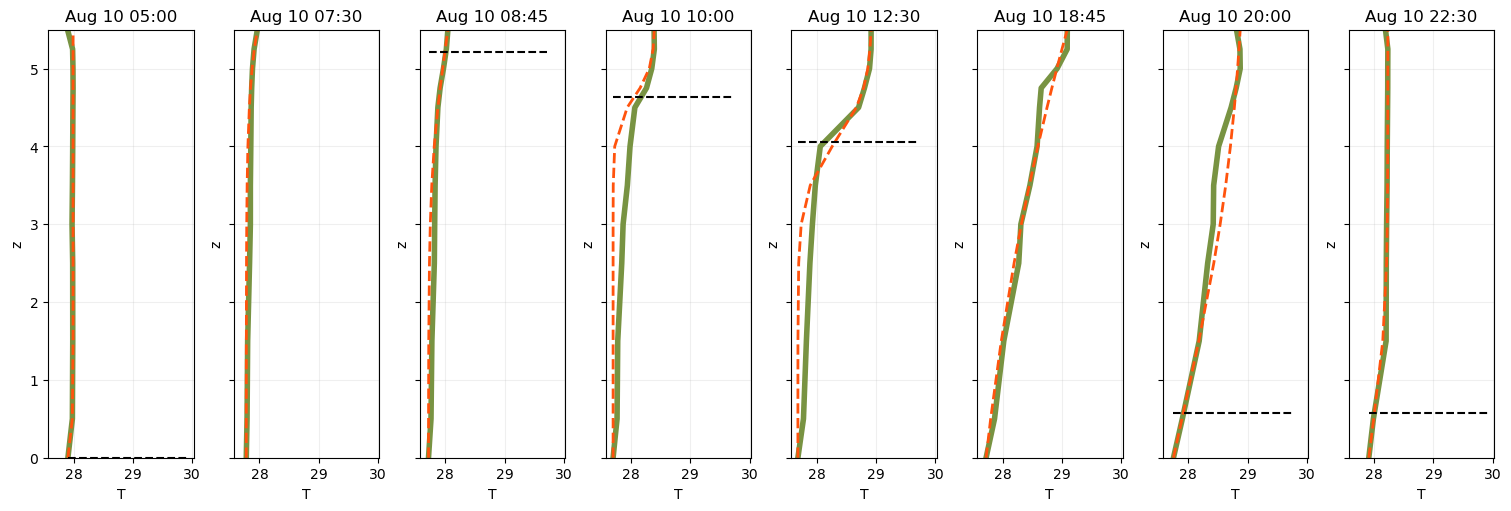

In [ ]:

temp = TEMP.loc[TEMP.SITE == 'WEB']
temp0 = temp.loc[temp.day == 10]
time = temp0.time.iloc[210: -70].values #Dates[ds.t.values]

pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
X = pivoted.columns.values
Y = pivoted.index.values
Z = pivoted.values

print(Z.shape)
z = np.flip(5.5 - Y) #np.flip(Y) 
print(z)
# z = np.linspace(0,10,100) #vertical coordinates, replace this with real data

def fitted_profile(z,A,C,lam):
    return A*(np.tanh((z-C)/lam)-np.tanh((z[0]-C)/lam))/(np.max(np.tanh((z-C)/lam)-np.tanh((z[0]-C)/lam)))

def RMSE_gradient(data,fitted,z):
    grad_data = np.gradient(data,z)
    grad_fitted = np.gradient(fitted,z)
    return np.sqrt(np.sum((grad_data-grad_fitted)**2)/len(grad_data))



fig, axs = plt.subplots(nrows=1, ncols=8, figsize=(15,5), sharex=True, sharey=True, constrained_layout=True)

# [40, 50, 60, 65, 70, 75, 80, 90]
for ix, index in enumerate([20, 30, 35, 40, 50,  75, 80, 90]):
    # index = 40
    #define some fake data (tanh profile + noise), replace this with real data 
    data = np.flip(Z[:,index]) # fitted_profile(z,10,5,1) + 0.4*(np.random.rand(100)-0.5)
    #normalize data so the first value is zero
    initial =  data[0]
    data = data - data[0]


    #search parameters to fit, choose ranges based on the real data 
    A_vals = [np.max(data)] #guess based on max temp diff
    C_vals = np.linspace(0, 11, 20)
    lam_vals = np.linspace(0.1, 8, 28)

    #variables for storing rmse and best parameters
    best_rmse = np.inf
    best_params = None

    #loop over parameters, minimise rmse between data and fitted curve
    for A in A_vals:
        for Carg,C in enumerate(C_vals):
            # print(int(np.max((C-10,0))),end='')
            for lam in lam_vals:
                fit = fitted_profile(z, A, C, lam)
                rmse = RMSE_gradient(data,fit,z=z)#np.max((Carg-1,10)))#int(np.max(C-10,0)))
                # print(start)
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_params = (A, C, lam)

    
    print('best params: A, C, lam = ',best_params)
    axs[ix].plot(data + initial, z, label='observed data', color="#789342", linewidth=4)
    axs[ix].plot(fitted_profile(z,best_params[0],best_params[1],best_params[2]) + initial,z, '--',label='fit', linewidth=2, color="#FF530D")
    # axs[ix].legend(loc='upper left')
    axs[ix].hlines(best_params[1], initial, initial+2, colors='k', linestyles='dashed', label='DWL')
    axs[ix].set_ylabel('z')
    axs[ix].set_xlabel('T')
    axs[ix].grid(alpha=0.2)
    axs[ix].set_ylim(min(z), max(z))
    time00 = pd.to_datetime(X[index])
    axs[ix].set_title("%s" % time00.strftime("%b %d %H:%M"))

    # fig = plt.figure(figsize=(5,5))
    # plt.plot(np.gradient(data,z),z, label='data')
    # plt.plot(np.gradient(fitted_profile(z,best_params[0],best_params[1],best_params[2]),z),
    #         z,label='fit')
    # plt.legend()
    # plt.ylabel('z')
    # plt.xlabel('dT/dz')

/tmp/ipykernel_2351786/3194317420.py:16: RuntimeWarning: invalid value encountered in divide
  return A*(np.tanh((z-C)/lam)-np.tanh((z[0]-C)/lam))/(np.max(np.tanh((z-C)/lam)-np.tanh((z[0]-C)/lam)))


Text(0.5, 0.98, 'height of thermocline (lambda) for each profile')

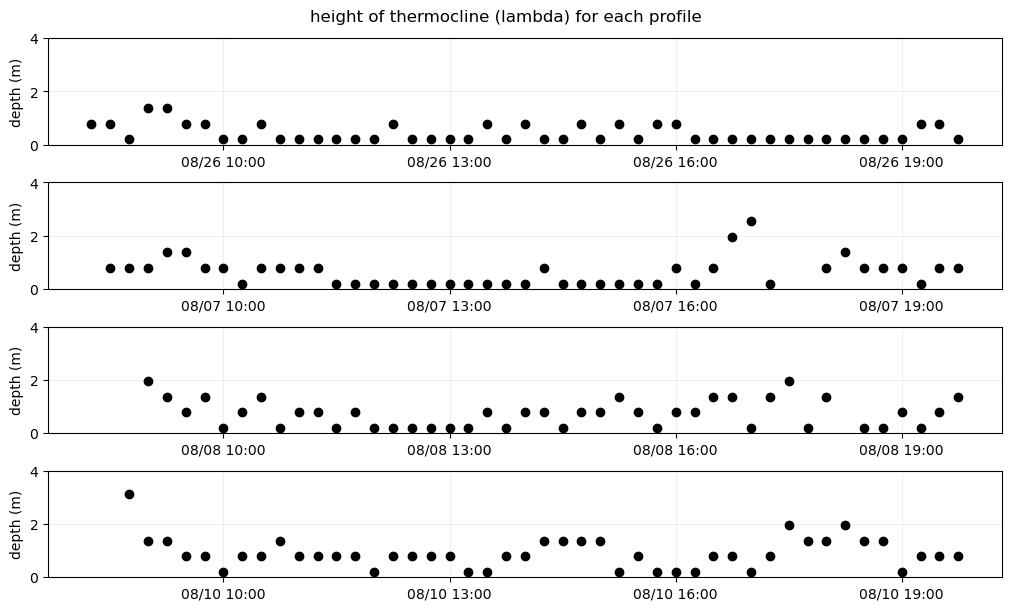

In [ ]:


temp = TEMP.loc[TEMP.SITE == 'WEB']


fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(10,6), sharex=False, sharey=True, constrained_layout=True)


for ix, day in enumerate([26, 7, 8, 10]):
    temp0 = temp.loc[temp.day == day]
    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values



    z = np.flip(5.5 - Y) 


    # fig = plt.figure(figsize=(9,3))
    # ax = plt.gca()

    for index in range(33, 80):


        # index = 40
        #define some fake data (tanh profile + noise), replace this with real data 
        data = np.flip(Z[:,index]) # fitted_profile(z,10,5,1) + 0.4*(np.random.rand(100)-0.5)
        #normalize data so the first value is zero
        initial =  data[0]
        data = data - data[0]


        #variables for storing rmse and best parameters
        best_rmse = np.inf
        best_params = None

        #loop over parameters, minimise rmse between data and fitted curve
        for A in A_vals:
            for Carg,C in enumerate(C_vals):
                for lam in lam_vals:
                    fit = fitted_profile(z, A, C, lam)
                    rmse = RMSE_gradient(data,fit,z=z)#np.max((Carg-1,10)))#int(np.max(C-10,0)))
                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_params = (A, C, lam)

        lam = best_params[2] * 2
        lam = np.clip(lam, 0, 5.5)

        axs[ix].plot(X[index], lam, 'o', color='k')

    format_date_ax(axs[ix], int=3)
    axs[ix].set_ylim(0, 4)
    axs[ix].grid(alpha=0.2)
    axs[ix].set_ylabel("depth (m)")

fig.suptitle("height of thermocline (lambda) for each profile")
    # print('best params: A, C, lam = ',best_params)
    # axs[ix].plot(data + initial, z, label='observed data', color="#789342", linewidth=4)
    # axs[ix].plot(fitted_profile(z,best_params[0],best_params[1],best_params[2]) + initial,z, '--',label='fit', linewidth=2, color="#FF530D")
    # # axs[ix].legend(loc='upper left')
    # axs[ix].set_ylabel('z')
    # axs[ix].set_xlabel('T')
    # axs[ix].grid(alpha=0.2)
    # axs[ix].set_ylim(min(z), max(z))

    # fig = plt.figure(figsize=(5,5))
    # plt.plot(np.gradient(data,z),z, label='data')
    # plt.plot(np.gradient(fitted_profile(z,best_params[0],best_params[1],best_params[2]),z),
    #         z,label='fit')
    # plt.legend()
    # plt.ylabel('z')
    # plt.xlabel('dT/dz')

{'TB', 'PLZ', 'WEB'}


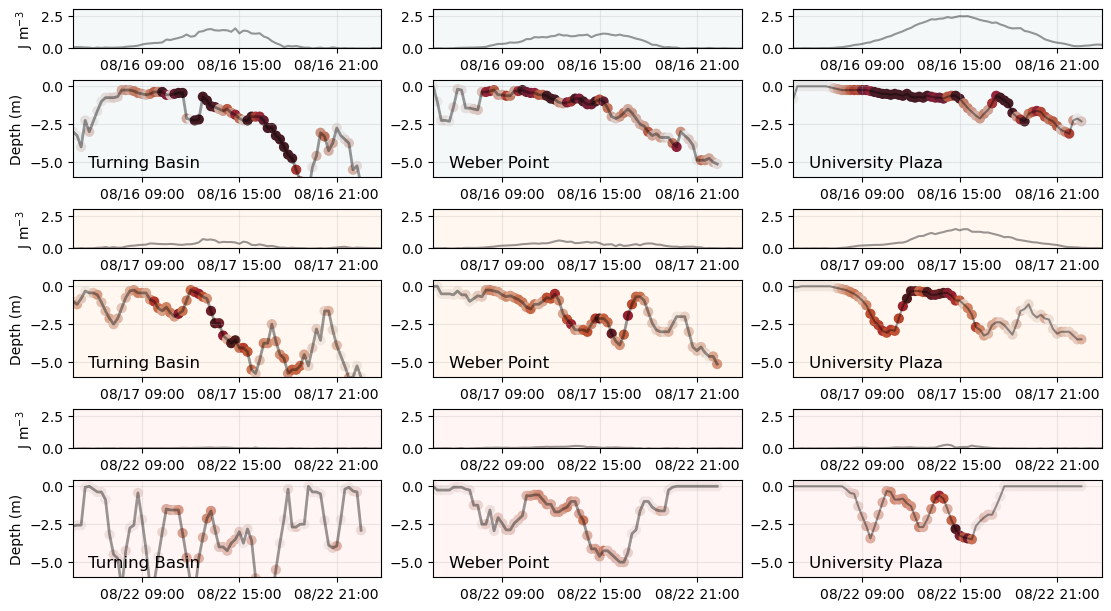

In [ ]:
pea = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/pea/TempDens_parameters.csv")
pea['time'] = pd.to_datetime(pea['TIMESTAMP'])

pea['pea_surf'] = pea['PE_Anomaly_surf3m (J/m^3)']
print(set(pea.SITE)) 

pea0 = pea.loc[pea.SITE == 'PLZ']
# assert(False)



dwl_tb = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/scripts/phys_obs_paper/DWL_output_TB.csv", parse_dates=['time'])
dwl_wp = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/scripts/phys_obs_paper/DWL_output_WEB.csv", parse_dates=['time'])
dwl_up = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/scripts/phys_obs_paper/DWL_output_PLZ.csv", parse_dates=['time'])


fig, axs = plt.subplots(nrows=6, ncols=3, figsize=(11,6), sharex='row', sharey=False, constrained_layout=True, height_ratios=[0.4, 1, 0.4, 1, 0.4, 1])
# axs = axs.flatten()
colors= [ "#99BECC", "#FFBA6C", "#FFA299"]
for i, d in enumerate([16, 17, 22]):
    dwl_up_day = dwl_up.loc[dwl_up.time.dt.day == d]

    ix = i*2 +1
    pea0 = pea.loc[pea.SITE == 'PLZ']
    axs[(i*2),2].plot(pea0.time, pea0.pea_surf, color="k", label="PLZ", alpha=0.4)

    axs[ix,2].plot(dwl_up_day.time, -dwl_up_day.dwl, color="k", label="PLZ", alpha=0.4)
    axs[ix,2].scatter(dwl_up_day.time, -dwl_up_day.dwl, c=dwl_up_day.grad, s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5)

    dwl_wp_day = dwl_wp.loc[dwl_wp.time.dt.day == d]
    axs[ix, 1].plot(dwl_wp_day.time, -dwl_wp_day.dwl, color="k", label="PLZ", alpha=0.4, linewidth=2)
    axs[ix, 1].scatter(dwl_wp_day.time, -dwl_wp_day.dwl, c=dwl_wp_day.grad, s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5)
    pea0 = pea.loc[pea.SITE == 'WEB']
    axs[(i*2),1].plot(pea0.time, pea0.pea_surf, color="k",  alpha=0.4)

    dwl_tb_day = dwl_tb.loc[dwl_tb.time.dt.day == d]
    axs[ix, 0].plot(dwl_tb_day.time, -dwl_tb_day.dwl, color="k", label="PLZ", alpha=0.4, linewidth=2)
    h= axs[ix, 0].scatter(dwl_tb_day.time, -dwl_tb_day.dwl, c=dwl_tb_day.grad, s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5)
    pea0 = pea.loc[pea.SITE == 'TB']
    axs[(i*2),0].plot(pea0.time, pea0.pea_surf, color="k",  alpha=0.4)


    # print(dwl_tb_day.time)
    axs[ix, 2].fill_between(dwl_tb_day.time, 1, -6, color=colors[i], alpha=0.1)
    axs[ix, 1].fill_between(dwl_tb_day.time,1, -6, color=colors[i], alpha=0.1)
    axs[ix, 0].fill_between(dwl_tb_day.time,1, -6, color=colors[i], alpha=0.1)
    axs[ix-1, 2].fill_between(dwl_tb_day.time, 3, 0, color=colors[i], alpha=0.1)
    axs[ix-1, 1].fill_between(dwl_tb_day.time, 3, 0, color=colors[i], alpha=0.1)
    axs[ix-1, 0].fill_between(dwl_tb_day.time, 3, 0, color=colors[i], alpha=0.1)


    axs[ix-1, 2].set_xlim(dwl_tb_day.time.values[19], dwl_tb_day.time.values[-1])

    axs[ix, 2].set_xlim(dwl_tb_day.time.values[19], dwl_tb_day.time.values[-1])
    axs[ix-1, 1].set_xlim(dwl_tb_day.time.values[19], dwl_tb_day.time.values[-1])

    axs[ix, 1].set_xlim(dwl_tb_day.time.values[19], dwl_tb_day.time.values[-1])
    axs[ix, 0].set_xlim(dwl_tb_day.time.values[19], dwl_tb_day.time.values[-1])
    axs[ix-1, 0].set_xlim(dwl_tb_day.time.values[19], dwl_tb_day.time.values[-1])
    
    
 


    axs[ix, 0].annotate("Turning Basin", (0.05, 0.1), xycoords='axes fraction', fontsize=12)
    axs[ix, 1].annotate("Weber Point", (0.05, 0.1), xycoords='axes fraction', fontsize=12)
    axs[ix, 2].annotate("University Plaza", (0.05, 0.1), xycoords='axes fraction', fontsize=12)


# axs[0, 2].set_title("Turning Basin")
# axs[0, 1].set_title("Weber Point")
# axs[0, 0].set_title("University Plaza")

axs[1, 0].set_ylabel("Depth (m)")
axs[3, 0].set_ylabel("Depth (m)")
axs[5, 0].set_ylabel("Depth (m)")


axs[0, 0].set_ylabel("J m$^{-3}$")
axs[2, 0].set_ylabel("J m$^{-3}$")
axs[4, 0].set_ylabel("J m$^{-3}$")


for i, ax in enumerate(axs.flatten()):
    format_date_ax(ax, int=6)
    row = i //3

    if row%2 ==1:
        ax.set_ylim(-6, 0.4)
    else:
        ax.set_ylim(0, 3)
    ax.grid(alpha=0.25)

# axs[0, 0].set_xticks([])
# axs[0, 1].set_xticks([])

# plt.colorbar(h, label=r'Temperature gradient ($^{\circ}$C m$^{-1}$)', shrink=0.35, orientation='horizontal', ax=axs[2])
# fig.savefig("%s/dwl_Ordered.png" % fout, dpi=300, bbox_inches="tight")

{'PLZ', 'TB', 'WEB'}


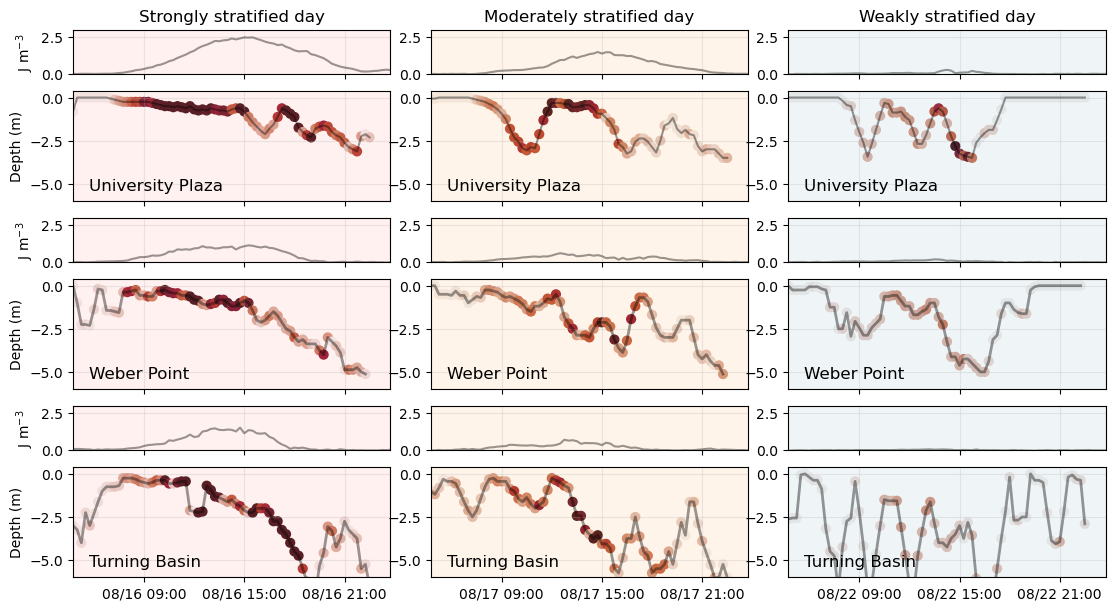

In [7]:
pea = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/pea/TempDens_parameters.csv")
pea['time'] = pd.to_datetime(pea['TIMESTAMP'])

pea['pea_surf'] = pea['PE_Anomaly_surf3m (J/m^3)']
print(set(pea.SITE)) 

pea0 = pea.loc[pea.SITE == 'PLZ']
# assert(False)



dwl_tb = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/scripts/phys_obs_paper/DWL_output_TB.csv", parse_dates=['time'])
dwl_wp = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/scripts/phys_obs_paper/DWL_output_WEB.csv", parse_dates=['time'])
dwl_up = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/scripts/phys_obs_paper/DWL_output_PLZ.csv", parse_dates=['time'])


fig, axs = plt.subplots(nrows=6, ncols=3, figsize=(11,6), sharex='col', sharey=False, constrained_layout=True, height_ratios=[0.4, 1, 0.4, 1, 0.4, 1])
# axs = axs.flatten()
colors= [ "#FFA299", "#FFBA6C", "#99BECC",]
for i, d in enumerate([16, 17, 22]):
    dwl_up_day = dwl_up.loc[dwl_up.time.dt.day == d]

    ix = i*2 +1
    pea0 = pea.loc[pea.SITE == 'PLZ']
    axs[0, i].plot(pea0.time, pea0.pea_surf, color="k", label="PLZ", alpha=0.4)

    axs[1,i].plot(dwl_up_day.time, -dwl_up_day.dwl, color="k", label="PLZ", alpha=0.4)
    axs[1,i].scatter(dwl_up_day.time, -dwl_up_day.dwl, c=dwl_up_day.grad, s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5)

    dwl_wp_day = dwl_wp.loc[dwl_wp.time.dt.day == d]
    axs[3, i].plot(dwl_wp_day.time, -dwl_wp_day.dwl, color="k", label="PLZ", alpha=0.4, linewidth=2)
    axs[3, i].scatter(dwl_wp_day.time, -dwl_wp_day.dwl, c=dwl_wp_day.grad, s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5)
    pea0 = pea.loc[pea.SITE == 'WEB']
    axs[2, i].plot(pea0.time, pea0.pea_surf, color="k",  alpha=0.4)

    dwl_tb_day = dwl_tb.loc[dwl_tb.time.dt.day == d]
    axs[5, i].plot(dwl_tb_day.time, -dwl_tb_day.dwl, color="k", label="PLZ", alpha=0.4, linewidth=2)
    h= axs[5, i].scatter(dwl_tb_day.time, -dwl_tb_day.dwl, c=dwl_tb_day.grad, s=40, cmap=cmo.cm.amp, vmin=0, vmax=1.5)
    pea0 = pea.loc[pea.SITE == 'TB']
    axs[4, i].plot(pea0.time, pea0.pea_surf, color="k",  alpha=0.4)


    # print(dwl_tb_day.time)
    for iax in range(6):
        axs[iax, i].fill_between(dwl_tb_day.time, 3, -6, color=colors[i], alpha=0.15)

    axs[0, i].set_xlim(dwl_tb_day.time.values[19], dwl_tb_day.time.values[-1])

    axs[5, i].annotate("Turning Basin", (0.05, 0.1), xycoords='axes fraction', fontsize=12)
    axs[3, i].annotate("Weber Point", (0.05, 0.1), xycoords='axes fraction', fontsize=12)
    axs[1, i].annotate("University Plaza", (0.05, 0.1), xycoords='axes fraction', fontsize=12)

axs[1, 0].set_ylabel("Depth (m)")
axs[3, 0].set_ylabel("Depth (m)")
axs[5, 0].set_ylabel("Depth (m)")


axs[0, 0].set_ylabel("J m$^{-3}$")
axs[2, 0].set_ylabel("J m$^{-3}$")
axs[4, 0].set_ylabel("J m$^{-3}$")


for i, ax in enumerate(axs.flatten()):
    format_date_ax(ax, int=6)
    row = i //3

    if row%2 ==1:
        ax.set_ylim(-6.0, 0.4)
    else:
        ax.set_ylim(0, 3)
    ax.grid(alpha=0.25)


axs[0, 0].set_title("Strongly stratified day")
axs[0, 1].set_title("Moderately stratified day")
axs[0, 2].set_title("Weakly stratified day")
# axs[0, 0].set_xticks([])
# axs[0, 1].set_xticks([])

# plt.colorbar(h, label=r'Temperature gradient ($^{\circ}$C m$^{-1}$)', shrink=0.35, orientation='horizontal', ax=axs[2])
fig.savefig("%s/dwl_ordered_flip.png" % fout, dpi=300, bbox_inches="tight")